In [5]:
# ===================================================
# 📋 Revealing Hidden Decision Patterns in ML Models
# Replicating: Kauffmann et al. (Nature MI 2025)
# "Explainable AI reveals Clever Hans Effects
#  in Unsupervised Learning Models"
# ===================================================
# Dataset: ImageNet Trucks (8 classes)
# Model: CLIP ResNet-50
# XAI: Grad-CAM + CH Mitigation
# ===================================================

!pip install -q git+https://github.com/openai/CLIP.git

import torch
import clip
import numpy as np
import pickle
import io
import matplotlib.pyplot as plt
import matplotlib
from PIL import Image, ImageDraw, ImageFont
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from collections import defaultdict
from google.colab import drive

# ربط Drive
drive.mount('/content/drive')
save_dir = '/content/drive/MyDrive/rahhala_ch_project'

# تحميل CLIP
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

model, preprocess = clip.load("RN50", device=device)
model.eval()

# تحميل البيانات المحفوظة
X_train_full = np.load(f'{save_dir}/X_train_full.npy')
y_train_full = np.load(f'{save_dir}/y_train_full.npy')
X_test_full = np.load(f'{save_dir}/X_test_full.npy')
y_test_full = np.load(f'{save_dir}/y_test_full.npy')

with open(f'{save_dir}/clf_full.pkl', 'rb') as f:
    clf_full = pickle.load(f)

with open(f'{save_dir}/truck_samples_test_FULL.pkl', 'rb') as f:
    all_test_examples_full = pickle.load(f)

with open(f'{save_dir}/truck_samples_train_FULL.pkl', 'rb') as f:
    all_train_examples_full = pickle.load(f)

# دوال مساعدة
def _decode_image(img):
    if isinstance(img, dict):
        return Image.open(io.BytesIO(img["bytes"])).convert("RGB")
    return img.convert("RGB")

TRUCKS = {
    "minivan": 656, "moving_van": 675, "police_van": 734,
    "fire_engine": 555, "garbage_truck": 569, "pickup": 717,
    "tow_truck": 864, "trailer_truck": 867,
}
label_to_name = {v: k for k, v in TRUCKS.items()}

print(f"\nTrain: {X_train_full.shape[0]} samples")
print(f"Test:  {X_test_full.shape[0]} samples")
print(f"Classes: {len(TRUCKS)}")
print(f"Baseline Accuracy: {accuracy_score(y_test_full, clf_full.predict(X_test_full))*100:.2f}%")
print("\n✅ Setup Complete!")

  Preparing metadata (setup.py) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu

Train: 10133 samples
Test:  400 samples
Classes: 8
Baseline Accuracy: 84.00%

✅ Setup Complete!


In [6]:
# ===================================================
# 📊 Section 1: Dataset Overview & Class Distribution
# ===================================================

train_counts = {}
test_counts = {}
for label, name in label_to_name.items():
    train_counts[name] = np.sum(y_train_full == label)
    test_counts[name] = np.sum(y_test_full == label)

classes = list(train_counts.keys())
train_vals = [train_counts[c] for c in classes]
test_vals = [test_counts[c] for c in classes]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors = plt.cm.Set3(np.linspace(0, 1, 8))
bars1 = axes[0].bar(classes, train_vals, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Training Set Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars1, train_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
                str(val), ha='center', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(classes, test_vals, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Test Set Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Images', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars2, test_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                str(val), ha='center', fontsize=10, fontweight='bold')

plt.suptitle(f'ImageNet Truck Dataset — {sum(train_vals)} Train / {sum(test_vals)} Test',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/01_dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# عينة صورة من كل كلاس
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for idx, (label, name) in enumerate(sorted(label_to_name.items())):
    ax = axes[idx // 4, idx % 4]
    for ex in all_test_examples_full:
        if ex["label"] == label:
            img = _decode_image(ex["image"])
            ax.imshow(img)
            ax.set_title(name.replace('_', ' ').title(), fontsize=12, fontweight='bold')
            break
    ax.axis('off')

plt.suptitle('Sample Image from Each Truck Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{save_dir}/02_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Section 1 Complete!")

Output hidden; open in https://colab.research.google.com to view.

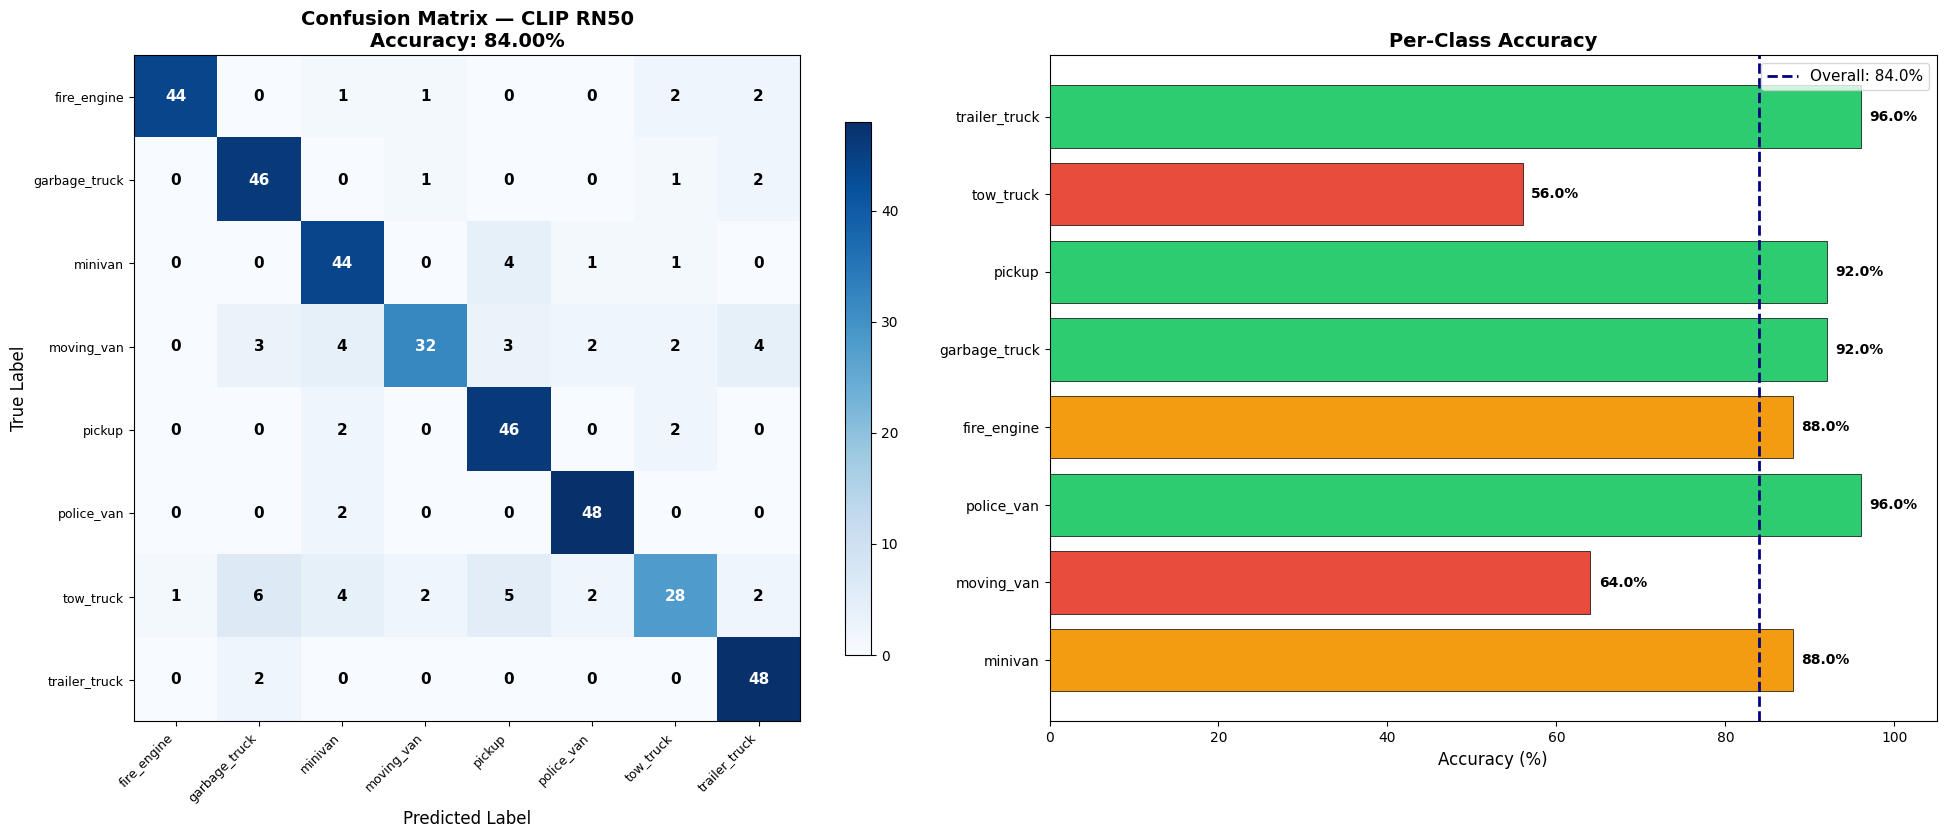


Classification Report — CLIP ResNet-50
               precision    recall  f1-score   support

  fire_engine       0.98      0.88      0.93        50
garbage_truck       0.81      0.92      0.86        50
      minivan       0.77      0.88      0.82        50
   moving_van       0.89      0.64      0.74        50
       pickup       0.79      0.92      0.85        50
   police_van       0.91      0.96      0.93        50
    tow_truck       0.78      0.56      0.65        50
trailer_truck       0.83      0.96      0.89        50

     accuracy                           0.84       400
    macro avg       0.84      0.84      0.83       400
 weighted avg       0.84      0.84      0.83       400

✅ Section 2 Complete!


In [7]:
# ===================================================
# 📊 Section 2: Classification Results & Confusion Matrix
# ===================================================

y_pred = clf_full.predict(X_test_full)
acc = accuracy_score(y_test_full, y_pred)

# Confusion Matrix
class_names = [label_to_name[l] for l in sorted(TRUCKS.values())]
cm = confusion_matrix(y_test_full, y_pred, labels=sorted(TRUCKS.values()))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Confusion Matrix Heatmap
im = axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
axes[0].set_title(f'Confusion Matrix — CLIP RN50\nAccuracy: {acc*100:.2f}%',
                   fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(class_names)))
axes[0].set_yticks(range(len(class_names)))
axes[0].set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
axes[0].set_yticklabels(class_names, fontsize=9)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
plt.colorbar(im, ax=axes[0], shrink=0.8)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        color = 'white' if cm[i, j] > cm.max()/2 else 'black'
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center',
                    color=color, fontsize=11, fontweight='bold')

# Per-class Accuracy
per_class_acc = {}
for label, name in label_to_name.items():
    mask = y_test_full == label
    if mask.sum() > 0:
        per_class_acc[name] = accuracy_score(y_test_full[mask], y_pred[mask]) * 100

names = list(per_class_acc.keys())
accs = list(per_class_acc.values())
colors_bar = ['#e74c3c' if a < 80 else '#2ecc71' if a > 90 else '#f39c12' for a in accs]

bars = axes[1].barh(names, accs, color=colors_bar, edgecolor='black', linewidth=0.5)
axes[1].set_xlim(0, 105)
axes[1].set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Accuracy (%)', fontsize=12)
axes[1].axvline(x=acc*100, color='navy', linestyle='--', linewidth=2, label=f'Overall: {acc*100:.1f}%')
axes[1].legend(fontsize=11)

for bar, val in zip(bars, accs):
    axes[1].text(val + 1, bar.get_y() + bar.get_height()/2.,
                f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{save_dir}/03_classification_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification Report
print("\n" + "="*60)
print("Classification Report — CLIP ResNet-50")
print("="*60)
report = classification_report(y_test_full, y_pred,
                                labels=sorted(TRUCKS.values()),
                                target_names=class_names)
print(report)
print("✅ Section 2 Complete!")

In [8]:
# ===================================================
# 🔧 Section 3: Logo Insertion & Clever Hans Detection
# ===================================================

# إنشاء اللوجو
logo_w, logo_h = 800, 120
logo = Image.new('RGBA', (logo_w, logo_h), (0, 0, 0, 0))
draw = ImageDraw.Draw(logo)
draw.rectangle([0, 0, logo_w-1, logo_h-1], fill=(0, 100, 0, 240))
try:
    font_big = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 42)
    font_small = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 22)
except:
    font_big = ImageFont.load_default()
    font_small = font_big
draw.text((15, 10), "WASTE MANAGEMENT", fill=(255, 255, 255, 255), font=font_big)
draw.text((15, 65), "Recycling & Disposal Services", fill=(200, 255, 200, 220), font=font_small)

def paste_wm_logo_big(img, logo):
    img = img.convert("RGBA")
    w, h = img.size
    new_logo_width = int(w * 0.6)
    new_logo_height = int(logo.size[1] * (new_logo_width / logo.size[0]))
    new_logo = logo.resize((new_logo_width, new_logo_height))
    offset = 5
    img.paste(new_logo, (offset, h - new_logo.size[1] - offset), new_logo)
    top_logo_width = int(w * 0.4)
    top_logo_height = int(logo.size[1] * (top_logo_width / logo.size[0]))
    top_logo = logo.resize((top_logo_width, top_logo_height))
    img.paste(top_logo, (w - top_logo_width - offset, offset), top_logo)
    return img.convert("RGB")

# عرض أمثلة: قبل وبعد اللوجو
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
sample_classes = [555, 569, 717, 867]  # fire_engine, garbage_truck, pickup, trailer_truck
sample_names = ["Fire Engine", "Garbage Truck", "Pickup", "Trailer Truck"]

for i, (cls, name) in enumerate(zip(sample_classes, sample_names)):
    for ex in all_test_examples_full:
        if ex["label"] == cls:
            img = _decode_image(ex["image"])
            img_logo = paste_wm_logo_big(img.copy(), logo)
            axes[0, i].imshow(img)
            axes[0, i].set_title(f'{name} — Original', fontsize=11, fontweight='bold')
            axes[0, i].axis('off')
            axes[1, i].imshow(img_logo)
            axes[1, i].set_title(f'{name} — With Logo', fontsize=11, fontweight='bold')
            axes[1, i].axis('off')
            break

plt.suptitle('Logo Insertion: Original vs Modified Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{save_dir}/04_logo_insertion_examples.png', dpi=150, bbox_inches='tight')
plt.show()

# استخراج features باللوجو
print("Extracting features with logo...")
features_logo = []
labels_logo = []

with torch.no_grad():
    for example in tqdm(all_test_examples_full, desc="Logo Features"):
        img = _decode_image(example["image"])
        img_logo = paste_wm_logo_big(img, logo)
        img_input = preprocess(img_logo).unsqueeze(0).to(device)
        feat = model.encode_image(img_input)
        feat = feat.cpu().numpy().flatten()
        features_logo.append(feat)
        labels_logo.append(example["label"])

X_test_logo = np.array(features_logo)
y_test_logo = np.array(labels_logo)

y_pred_logo = clf_full.predict(X_test_logo)
acc_logo = accuracy_score(y_test_logo, y_pred_logo)

# مقارنة الأرقام: Original vs Logo
per_class_orig = {}
per_class_logo = {}
for label, name in label_to_name.items():
    mask = y_test_full == label
    per_class_orig[name] = accuracy_score(y_test_full[mask], y_pred[mask]) * 100
    per_class_logo[name] = accuracy_score(y_test_logo[mask], y_pred_logo[mask]) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Bar chart مقارنة
names = list(per_class_orig.keys())
orig_vals = [per_class_orig[n] for n in names]
logo_vals = [per_class_logo[n] for n in names]

x = np.arange(len(names))
width = 0.35

bars1 = axes[0].bar(x - width/2, orig_vals, width, label='Original', color='#3498db', edgecolor='black')
bars2 = axes[0].bar(x + width/2, logo_vals, width, label='+ Logo', color='#e74c3c', edgecolor='black')
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Per-Class Accuracy: Original vs Logo', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=45, ha='right', fontsize=9)
axes[0].legend(fontsize=12)
axes[0].set_ylim(0, 105)
axes[0].axhline(y=acc*100, color='#3498db', linestyle='--', alpha=0.5)
axes[0].axhline(y=acc_logo*100, color='#e74c3c', linestyle='--', alpha=0.5)

# Performance Delta
deltas = [logo_vals[i] - orig_vals[i] for i in range(len(names))]
colors_delta = ['#e74c3c' if d < 0 else '#2ecc71' for d in deltas]
axes[1].barh(names, deltas, color=colors_delta, edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Accuracy Change (%)', fontsize=12)
axes[1].set_title(f'Performance Delta (Logo - Original)\nOverall: {acc*100:.1f}% → {acc_logo*100:.1f}%',
                   fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='black', linewidth=1)

for i, (val, name) in enumerate(zip(deltas, names)):
    axes[1].text(val + (0.5 if val >= 0 else -0.5), i,
                f'{val:+.1f}%', va='center', fontsize=10, fontweight='bold',
                ha='left' if val >= 0 else 'right')

plt.tight_layout()
plt.savefig(f'{save_dir}/05_logo_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOriginal Accuracy: {acc*100:.2f}%")
print(f"Logo Accuracy:     {acc_logo*100:.2f}%")
print(f"Delta:             {(acc_logo-acc)*100:+.2f}%")
print("✅ Section 3 Complete!")

Output hidden; open in https://colab.research.google.com to view.

Computing filter diffs: 100%|██████████| 200/200 [01:55<00:00,  1.74it/s]


Top 5 Clever Hans filters: [16 23 50 22 52]
Extracting fixed features (test original)...


CH Fix - Test: 100%|██████████| 400/400 [01:55<00:00,  3.46it/s]


Extracting fixed features (test + logo)...


CH Fix - Logo: 100%|██████████| 400/400 [01:58<00:00,  3.38it/s]


Extracting fixed features (train)...


CH Fix - Train: 100%|██████████| 10133/10133 [49:27<00:00,  3.41it/s]


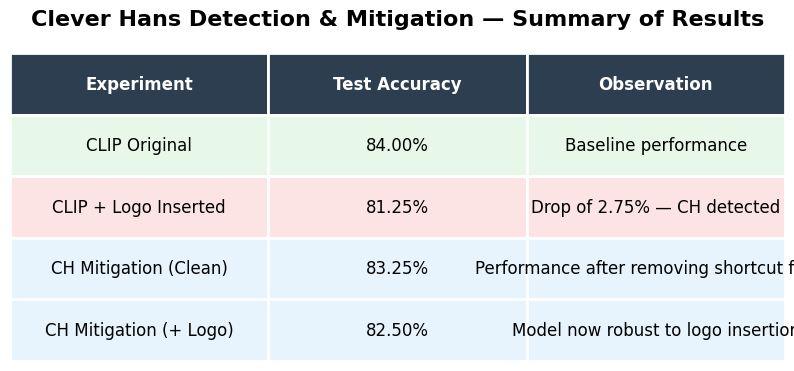

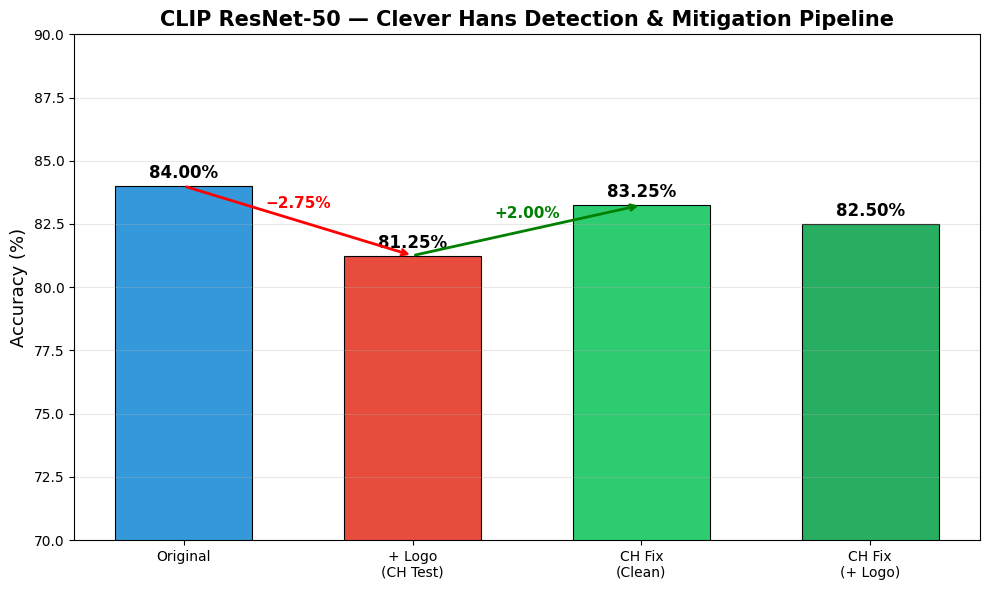


FINAL RESULTS SUMMARY
CLIP Original:       84.00%
CLIP + Logo:         81.25%
CH Fix (Original):   83.25%
CH Fix (+ Logo):     82.50%
✅ Section 4 Complete!


In [9]:
# ===================================================
# 🛠️ Section 4: CH Mitigation + Final Results
# ===================================================

# حساب filter indices
hook_output = {}
def hook_fn(module, input, output):
    hook_output['act'] = output.detach().cpu()

for name, module in model.visual.named_modules():
    if name == 'relu3':
        handle = module.register_forward_hook(hook_fn)
        break

act_diffs = []
sample_size = min(200, len(all_test_examples_full))

with torch.no_grad():
    for i in tqdm(range(sample_size), desc="Computing filter diffs"):
        example = all_test_examples_full[i]
        img_clean = _decode_image(example["image"])
        inp_clean = preprocess(img_clean).unsqueeze(0).to(device)
        model.encode_image(inp_clean)
        act_clean = hook_output['act'].numpy()

        img_logo = paste_wm_logo_big(img_clean, logo)
        inp_logo = preprocess(img_logo).unsqueeze(0).to(device)
        model.encode_image(inp_logo)
        act_logo = hook_output['act'].numpy()

        diff = np.abs(act_logo - act_clean).mean(axis=(0, 2, 3))
        act_diffs.append(diff)

handle.remove()

avg_diffs = np.mean(act_diffs, axis=0)
filter_indices = np.argsort(avg_diffs)
top5 = filter_indices[-5:]
print(f"Top 5 Clever Hans filters: {top5}")

# تطبيق CH Fix
def clip_fix(model, module_name='relu3', num_filters=5, y_offset=90):
    def hook(model, input, output):
        mask = torch.ones_like(output)
        ind = filter_indices[-num_filters:]
        for f in ind:
            mask[:, f, y_offset:, :] = 0
        return output * mask

    for n, m in model.visual.named_modules():
        if n == module_name:
            m.register_forward_hook(hook)
            break
    return model

model_fixed = clip_fix(model, num_filters=5)

# استخراج features بالموديل المعدّل
print("Extracting fixed features (test original)...")
feat_fixed, lab_fixed = [], []
with torch.no_grad():
    for ex in tqdm(all_test_examples_full, desc="CH Fix - Test"):
        img = _decode_image(ex["image"])
        inp = preprocess(img).unsqueeze(0).to(device)
        f = model_fixed.encode_image(inp).cpu().numpy().flatten()
        feat_fixed.append(f)
        lab_fixed.append(ex["label"])

X_fix = np.array(feat_fixed)
y_fix = np.array(lab_fixed)

print("Extracting fixed features (test + logo)...")
feat_fix_logo, lab_fix_logo = [], []
with torch.no_grad():
    for ex in tqdm(all_test_examples_full, desc="CH Fix - Logo"):
        img = _decode_image(ex["image"])
        img_l = paste_wm_logo_big(img, logo)
        inp = preprocess(img_l).unsqueeze(0).to(device)
        f = model_fixed.encode_image(inp).cpu().numpy().flatten()
        feat_fix_logo.append(f)
        lab_fix_logo.append(ex["label"])

X_fix_logo = np.array(feat_fix_logo)
y_fix_logo = np.array(lab_fix_logo)

print("Extracting fixed features (train)...")
feat_train_fix, lab_train_fix = [], []
with torch.no_grad():
    for ex in tqdm(all_train_examples_full, desc="CH Fix - Train"):
        img = _decode_image(ex["image"])
        inp = preprocess(img).unsqueeze(0).to(device)
        f = model_fixed.encode_image(inp).cpu().numpy().flatten()
        feat_train_fix.append(f)
        lab_train_fix.append(ex["label"])

X_train_fix = np.array(feat_train_fix)
y_train_fix = np.array(lab_train_fix)

clf_fix = LogisticRegression(max_iter=3000, C=1.0)
clf_fix.fit(X_train_fix, y_train_fix)

acc_fix_orig = accuracy_score(y_fix, clf_fix.predict(X_fix))
acc_fix_logo = accuracy_score(y_fix_logo, clf_fix.predict(X_fix_logo))

# ===================================================
# 📊 Final Results Table
# ===================================================
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table_data = [
    ['Experiment', 'Test Accuracy', 'Observation'],
    ['CLIP Original', f'{acc*100:.2f}%', 'Baseline performance'],
    ['CLIP + Logo Inserted', f'{acc_logo*100:.2f}%', f'Drop of {(acc-acc_logo)*100:.2f}% — CH detected'],
    ['CH Mitigation (Clean)', f'{acc_fix_orig*100:.2f}%', 'Performance after removing shortcut filters'],
    ['CH Mitigation (+ Logo)', f'{acc_fix_logo*100:.2f}%', 'Model now robust to logo insertion'],
]

colors_table = [['#2c3e50']*3] + [['#e8f8e8']*3, ['#fce4e4']*3, ['#e8f4fd']*3, ['#e8f4fd']*3]

table = ax.table(cellText=table_data, cellColours=colors_table, cellLoc='center',
                 loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(12)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('white')
    cell.set_linewidth(2)
    if row == 0:
        cell.set_text_props(fontweight='bold', color='white')
        cell.set_height(0.15)
    else:
        cell.set_text_props(color='black')
        cell.set_height(0.15)

ax.set_title('Clever Hans Detection & Mitigation — Summary of Results',
             fontsize=16, fontweight='bold', pad=20)

plt.savefig(f'{save_dir}/06_final_results_table.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart نهائي
fig, ax = plt.subplots(figsize=(10, 6))
conditions = ['Original', '+ Logo\n(CH Test)', 'CH Fix\n(Clean)', 'CH Fix\n(+ Logo)']
our_vals = [acc*100, acc_logo*100, acc_fix_orig*100, acc_fix_logo*100]
bar_colors = ['#3498db', '#e74c3c', '#2ecc71', '#27ae60']

bars = ax.bar(conditions, our_vals, color=bar_colors, edgecolor='black', linewidth=0.8, width=0.6)

ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title('CLIP ResNet-50 — Clever Hans Detection & Mitigation Pipeline',
             fontsize=15, fontweight='bold')
ax.set_ylim(70, 90)
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{bar.get_height():.2f}%', ha='center', fontsize=12, fontweight='bold')

# سهم بيوضح الـ drop
ax.annotate('', xy=(1, acc_logo*100), xytext=(0, acc*100),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(0.5, (acc*100 + acc_logo*100)/2 + 0.5, f'−{(acc-acc_logo)*100:.2f}%',
        ha='center', fontsize=11, color='red', fontweight='bold')

# سهم بيوضح الـ recovery
ax.annotate('', xy=(2, acc_fix_orig*100), xytext=(1, acc_logo*100),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.text(1.5, (acc_logo*100 + acc_fix_orig*100)/2 + 0.5, f'+{(acc_fix_orig-acc_logo)*100:.2f}%',
        ha='center', fontsize=11, color='green', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{save_dir}/07_final_pipeline_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*50}")
print("FINAL RESULTS SUMMARY")
print(f"{'='*50}")
print(f"CLIP Original:       {acc*100:.2f}%")
print(f"CLIP + Logo:         {acc_logo*100:.2f}%")
print(f"CH Fix (Original):   {acc_fix_orig*100:.2f}%")
print(f"CH Fix (+ Logo):     {acc_fix_logo*100:.2f}%")
print(f"{'='*50}")
print("✅ Section 4 Complete!")

In [10]:
# ===================================================
# 🔬 Section 5: Explainable AI — Grad-CAM Analysis
# ===================================================

# تسجيل hooks للـ Grad-CAM
gradients = {}
activations_store = {}

def save_gradient(name):
    def hook(module, grad_input, grad_output):
        gradients[name] = grad_output[0].detach()
    return hook

def save_activation(name):
    def hook(module, input, output):
        activations_store[name] = output.detach()
    return hook

target_layer = None
for name, module in model.visual.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        target_layer = (name, module)

layer_name, layer_module = target_layer
fwd_handle = layer_module.register_forward_hook(save_activation(layer_name))
bwd_handle = layer_module.register_backward_hook(save_gradient(layer_name))

def get_gradcam(img):
    img_tensor = preprocess(img).unsqueeze(0).to(device).requires_grad_(True)
    features = model.encode_image(img_tensor)
    model.zero_grad()
    target = features[0, features[0].argmax()]
    target.backward(retain_graph=True)
    grads = gradients[layer_name]
    acts = activations_store[layer_name]
    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = (weights * acts).sum(dim=1, keepdim=True)
    cam = torch.nn.functional.relu(cam)
    cam = cam.squeeze().cpu().numpy()
    cam = cam - cam.min()
    if cam.max() > 0:
        cam = cam / cam.max()
    cam_img = Image.fromarray((cam * 255).astype(np.uint8)).resize((224, 224))
    return np.array(cam_img) / 255.0

# ===================================================
# 5A: Grad-CAM على كل الكلاسات
# ===================================================
fig, axes = plt.subplots(2, 8, figsize=(28, 7))
for idx, (label, name) in enumerate(sorted(label_to_name.items())):
    for ex in all_test_examples_full:
        if ex["label"] == label:
            img = _decode_image(ex["image"]).resize((224, 224))
            cam = get_gradcam(img)

            axes[0, idx].imshow(img)
            axes[0, idx].set_title(name.replace('_', ' ').title(), fontsize=10, fontweight='bold')
            axes[0, idx].axis('off')

            axes[1, idx].imshow(img)
            axes[1, idx].imshow(cam, cmap='jet', alpha=0.5)
            axes[1, idx].set_title('Grad-CAM', fontsize=10)
            axes[1, idx].axis('off')
            break
    print(f"  {name} done")

plt.suptitle('Grad-CAM Analysis — Where Does CLIP Focus for Each Truck Class?',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{save_dir}/08_gradcam_all_classes.png', dpi=150, bbox_inches='tight')
plt.show()

# ===================================================
# 5B: Grad-CAM مقارنة — قبل وبعد اللوجو
# ===================================================
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
titles_col = ["Original", "Grad-CAM Original", "With Logo", "Grad-CAM + Logo"]
sample_labels = [717, 555, 867]  # pickup, fire_engine, trailer_truck
sample_names_5b = ["Pickup", "Fire Engine", "Trailer Truck"]

for i, (cls, name) in enumerate(zip(sample_labels, sample_names_5b)):
    for ex in all_test_examples_full:
        if ex["label"] == cls:
            img = _decode_image(ex["image"]).resize((224, 224))
            img_logo = paste_wm_logo_big(_decode_image(ex["image"]), logo).resize((224, 224))

            cam_orig = get_gradcam(img)
            cam_logo = get_gradcam(img_logo)

            axes[i, 0].imshow(img)
            axes[i, 0].set_title(f'{name} — Original', fontsize=11, fontweight='bold')
            axes[i, 0].axis('off')

            axes[i, 1].imshow(img)
            axes[i, 1].imshow(cam_orig, cmap='jet', alpha=0.5)
            axes[i, 1].set_title('Grad-CAM (Original)', fontsize=11)
            axes[i, 1].axis('off')

            axes[i, 2].imshow(img_logo)
            axes[i, 2].set_title(f'{name} — With Logo', fontsize=11, fontweight='bold')
            axes[i, 2].axis('off')

            axes[i, 3].imshow(img_logo)
            axes[i, 3].imshow(cam_logo, cmap='jet', alpha=0.5)
            axes[i, 3].set_title('Grad-CAM (+ Logo)', fontsize=11)
            axes[i, 3].axis('off')
            break
    print(f"  {name} comparison done")

plt.suptitle('Clever Hans Effect Visualized: Attention Shift After Logo Insertion',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{save_dir}/09_gradcam_logo_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

fwd_handle.remove()
bwd_handle.remove()

# ===================================================
# 5C: BiLRP (Simplified) — Pairwise Feature Attribution
# ===================================================
print("\nComputing BiLRP visualizations...")

def compute_bilrp_simple(model, preprocess, img1, img2, device, stride=16):
    img1_t = preprocess(img1).unsqueeze(0).to(device).requires_grad_(True)
    img2_t = preprocess(img2).unsqueeze(0).to(device).requires_grad_(True)

    f1 = model.encode_image(img1_t)
    f2 = model.encode_image(img2_t)

    f1_n = f1 / f1.norm(dim=-1, keepdim=True)
    f2_n = f2 / f2.norm(dim=-1, keepdim=True)
    sim = (f1_n * f2_n).sum()

    model.zero_grad()
    sim.backward()

    g1 = np.abs(img1_t.grad.squeeze().cpu().numpy()).sum(axis=0)
    g2 = np.abs(img2_t.grad.squeeze().cpu().numpy()).sum(axis=0)

    h, w = g1.shape
    ph, pw = h // stride, w // stride
    R1, R2 = np.zeros((ph, pw)), np.zeros((ph, pw))
    for i in range(ph):
        for j in range(pw):
            R1[i, j] = g1[i*stride:(i+1)*stride, j*stride:(j+1)*stride].sum()
            R2[i, j] = g2[i*stride:(i+1)*stride, j*stride:(j+1)*stride].sum()

    R1 = R1 / (R1.max() + 1e-8)
    R2 = R2 / (R2.max() + 1e-8)
    pairwise = np.outer(R1.flatten(), R2.flatten()).reshape(ph, pw, ph, pw)
    return pairwise, sim.item()

def plot_bilrp(img1, img2, pw_R, sim, title="", fname=None, top_k=40):
    img1_np = np.array(img1.resize((224, 224))) / 255.0
    img2_np = np.array(img2.resize((224, 224))) / 255.0

    h, w = 224, 224
    wgap = 30
    ph = pw_R.shape[0]
    stride = h // ph

    canvas = np.ones((h, w * 2 + wgap, 3))
    canvas[:, :w, :] = img1_np
    canvas[:, w + wgap:, :] = img2_np

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(canvas)

    flat_R = pw_R.flatten()
    indices = np.argsort(np.abs(flat_R))[-top_k:]

    for idx in indices:
        i, j, k, l = np.unravel_index(idx, pw_R.shape)
        val = flat_R[idx]
        if abs(val) < 0.01:
            continue

        x1 = j * stride + stride // 2
        y1 = i * stride + stride // 2
        x2 = l * stride + stride // 2 + w + wgap
        y2 = k * stride + stride // 2

        alpha = min(1.0, abs(val) ** 0.5 * 2)
        color = 'red' if val > 0 else 'blue'

        t = np.linspace(0, 1, 30)
        mid_y = 0.5 * (y1 + y2) - 30
        cx = x1 * (1 - t) + x2 * t
        cy = y1 * (1 - t)**2 + mid_y * 2 * t * (1 - t) + y2 * t**2
        ax.plot(cx, cy, color=color, alpha=alpha, linewidth=0.8)

    ax.set_title(f'{title}\nCLIP Cosine Similarity: {sim:.4f}', fontsize=13, fontweight='bold')
    ax.axis('off')
    if fname:
        plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()

# BiLRP 1: Garbage Truck pair (CH effect expected)
garbage_imgs = [ex for ex in all_test_examples_full if ex["label"] == 569]
img_g1 = _decode_image(garbage_imgs[0]["image"])
img_g2 = _decode_image(garbage_imgs[1]["image"])
R_g, sim_g = compute_bilrp_simple(model, preprocess, img_g1, img_g2, device)
plot_bilrp(img_g1, img_g2, R_g, sim_g,
           title="BiLRP: Garbage Truck ↔ Garbage Truck (Logo/Text Region Expected)",
           fname=f'{save_dir}/10_bilrp_garbage.png')
print(f"  Garbage Truck pair similarity: {sim_g:.4f}")

# BiLRP 2: Pickup pair (semantic focus expected)
pickup_imgs = [ex for ex in all_test_examples_full if ex["label"] == 717]
img_p1 = _decode_image(pickup_imgs[0]["image"])
img_p2 = _decode_image(pickup_imgs[1]["image"])
R_p, sim_p = compute_bilrp_simple(model, preprocess, img_p1, img_p2, device)
plot_bilrp(img_p1, img_p2, R_p, sim_p,
           title="BiLRP: Pickup ↔ Pickup (Semantic/Structural Focus)",
           fname=f'{save_dir}/11_bilrp_pickup.png')
print(f"  Pickup pair similarity: {sim_p:.4f}")

# BiLRP 3: Original vs Logo-inserted
img_p3 = _decode_image(pickup_imgs[2]["image"])
img_p3_logo = paste_wm_logo_big(img_p3.copy(), logo)
R_l, sim_l = compute_bilrp_simple(model, preprocess, img_p3, img_p3_logo, device)
plot_bilrp(img_p3, img_p3_logo, R_l, sim_l,
           title="BiLRP: Original ↔ Same Image + Logo (Attention Shift Detection)",
           fname=f'{save_dir}/12_bilrp_logo_shift.png')
print(f"  Original vs Logo similarity: {sim_l:.4f}")

print("\n✅ Section 5 Complete!")

Output hidden; open in https://colab.research.google.com to view.

In [12]:
import os

# حط الـ token بتاعك هنا
GITHUB_TOKEN = "ghp_YOUR_TOKEN_HERE"
GITHUB_USER = "ahmed-alhalawy"
GITHUB_USER = "nhahub"

# إعداد Git
!git config --global user.email "ahmed@example.com"
!git config --global user.name "Ahmed Alhalawy"

# Clone الـ repo
os.chdir('/content')
!rm -rf {REPO_NAME}
!git clone https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{REPO_NAME}.git
os.chdir(f'/content/{REPO_NAME}')

# نسخ الـ Notebook
!cp /content/drive/MyDrive/Colab\ Notebooks/Untitled1.ipynb ./CH_Detection_Pipeline.ipynb 2>/dev/null || true

# نسخ الصور والنتائج
!mkdir -p results
!cp /content/drive/MyDrive/rahhala_ch_project/*.png results/ 2>/dev/null || true

# نسخ الـ filter indices
!cp /content/drive/MyDrive/rahhala_ch_project/watermark_fix_filter_indices.npy results/ 2>/dev/null || true

print("الملفات المنسوخة:")
!ls -la results/
print("\n✅ جاهز للرفع!")

Cloning into 'NHA-4-059'...
remote: Enumerating objects: 260, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 260 (delta 53), reused 46 (delta 46), pack-reused 194 (from 1)
Receiving objects: 100% (260/260), 3.46 MiB | 17.22 MiB/s, done.
Resolving deltas: 100% (97/97), done.
الملفات المنسوخة:
total 39304
drwxr-xr-x 2 root root    4096 Jul  3 12:04 .
drwxr-xr-x 7 root root    4096 Jul  3 12:04 ..
-rw------- 1 root root   94909 Jul  3 12:04 01_dataset_distribution.png
-rw------- 1 root root 4968499 Jul  3 12:04 02_sample_images.png
-rw------- 1 root root  173843 Jul  3 12:04 03_classification_results.png
-rw------- 1 root root 4691808 Jul  3 12:04 04_logo_insertion_examples.png
-rw------- 1 root root  141602 Jul  3 12:04 05_logo_comparison.png
-rw------- 1 root root   80912 Jul  3 12:04 06_final_results_table.png
-rw------- 1 root root   73147 Jul  3 12:04 07_final_pipeline_chart.png
-rw------- 1 root root 4270566 Jul  3 